# Germline Variant Analysis — CEPH Trio (NA12878 / NA12891 / NA12892)

This notebook explores the output of the germline variant calling pipeline:
HaplotypeCaller GVCF → CombineGVCFs → GenotypeGVCFs → hard filters → annotation.

**Data**: chr20 subset, CEPH trio  
**Samples**: NA12878 (mother / GIAB benchmark), NA12891 (father), NA12892 (son)  
**Caller**: GATK HaplotypeCaller v4.4 (GVCF workflow)  
**Annotation**: VEP REST + gnomAD + ClinVar + CADD

---
## Learning objectives
1. Understand joint genotyping output (multi-sample VCF)
2. Apply ACMG classification criteria using annotation data
3. Identify rare variants and de novo candidates
4. Interpret population frequency in the context of disease relevance
5. Understand HGVS notation for germline variants

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 120

ANNOTATED_TSV = '../../results/germline/annotated/annotated.tsv'
INTERPRETED   = '../../results/germline/annotated/interpreted.json'

print('Loading annotated germline variants...')
df = pd.read_csv(ANNOTATED_TSV, sep='\t', low_memory=False)
print(f'Loaded {len(df)} PASS germline variants')
df.head(3)

Loading annotated germline variants...
Loaded 1111 PASS germline variants


,chrom,pos,ref,alt,filter,gene_symbol,ensembl_gene_id,gene_biotype,transcript_id,is_canonical,...,civic_evidence_type,civic_clinical_significance,civic_drug,civic_cancer_type,vaf,depth,genotype,existing_variation,regulatory_id,af_1kg
0,20,9999900,G,C,PASS,ANKEF1,ENSG00000132623,processed_transcript,ENST00000437504,NO,...,.,.,.,.,.,"8,2,4",.,.,.,.
1,20,9999996,A,ACT,PASS,ANKEF1,ENSG00000132623,processed_transcript,ENST00000437504,NO,...,.,.,.,.,.,"13,13,18",.,.,.,.
2,20,10000117,C,T,PASS,ANKEF1,ENSG00000132623,processed_transcript,ENST00000437504,NO,...,.,.,.,.,.,"32,23,30",.,.,.,.


In [2]:
df.columns

Index(['chrom', 'pos', 'ref', 'alt', 'filter', 'gene_symbol',
       'ensembl_gene_id', 'gene_biotype', 'transcript_id', 'is_canonical',
       'mane_select', 'consequence', 'impact', 'exon', 'intron', 'hgvsg',
       'hgvsc', 'hgvsp', 'amino_acids', 'codons', 'cdna_position',
       'cds_position', 'protein_position', 'sift_score', 'sift_pred',
       'polyphen_score', 'polyphen_pred', 'phylop', 'gerp', 'cadd_raw',
       'cadd_phred', 'gnomad_af', 'gnomad_popmax_af', 'gnomad_popmax_pop',
       'gnomad_afr_af', 'gnomad_amr_af', 'gnomad_asj_af', 'gnomad_eas_af',
       'gnomad_fin_af', 'gnomad_nfe_af', 'gnomad_sas_af', 'gnomad_mid_af',
       'clinvar_clnsig', 'clinvar_review_stars', 'clinvar_clndn',
       'clinvar_review_status', 'clinvar_last_evaluated',
       'civic_evidence_level', 'civic_evidence_type',
       'civic_clinical_significance', 'civic_drug', 'civic_cancer_type', 'vaf',
       'depth', 'genotype', 'existing_variation', 'regulatory_id', 'af_1kg'],
      dtype='object

## 1. Callset Overview

For chr20 with a well-characterized trio, we expect:
- ~5,000–15,000 PASS SNPs
- ~500–2,000 PASS Indels  
- SNP Ts/Tv ratio ~2.0–2.1 (WGS)  
- ~1–3 de novo candidates (mutation rate ~1.2×10⁻⁸ per bp per generation)

In [3]:
print('=== Callset Overview ===')
print(f'Total PASS variants: {len(df)}')

snp_mask   = (df.ref.str.len() == 1) & (df.alt.str.len() == 1)
indel_mask = ~snp_mask
print(f'\nVariant types:')
print(f'  SNPs:   {snp_mask.sum()}')
print(f'  Indels: {indel_mask.sum()}')

print(f'\nConsequence IMPACT distribution:')
print(df['impact'].value_counts().to_string())

print(f'\nGenotype distributions (son column):')
# Genotype is stored as comma-separated mother,father,son
if df['genotype'].str.contains(',').any():
    son_gt = df['genotype'].str.split(',').str[-1]
    print(son_gt.value_counts().to_string())
else:
    print(df['genotype'].value_counts().to_string())

=== Callset Overview ===
Total PASS variants: 1111

Variant types:
  SNPs:   894
  Indels: 217

Consequence IMPACT distribution:
impact
MODIFIER    914
.           192
LOW           3
MODERATE      2

Genotype distributions (son column):
genotype
.    1111


# Parse depth (may be comma-separated for trio)
def parse_first_depth(d):
    try:
        return float(str(d).split(',')[0])
    except Exception:
        return np.nan

df['depth_num'] = df['depth'].apply(parse_first_depth)
depth_clean = df['depth_num'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Depth histogram ───────────────────────────────────────────────────
axes[0].hist(depth_clean.clip(upper=150), bins=40,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(20,  color='orange', linestyle='--', linewidth=1.5, label='Min (20×)')
axes[0].axvline(100, color='red',    linestyle='--', linewidth=1.5, label='High (100×)')
axes[0].set_xlabel('Sequencing Depth (DP)')
axes[0].set_ylabel('Number of Variants')
axes[0].set_title('Depth Distribution (PASS variants)')
axes[0].legend(fontsize=9)
print(f'Median depth: {depth_clean.median():.0f}×')
print(f'Low depth (<20×): {(depth_clean < 20).sum()} ({(depth_clean < 20).mean()*100:.1f}%)')

# ── Right: Impact bar chart (replaces pie — labels don't overlap) ──────────
impact_counts = df['impact'].value_counts().reindex(
    ['HIGH', 'MODERATE', 'LOW', 'MODIFIER'], fill_value=0)
colors_impact = {'HIGH': '#d62728', 'MODERATE': '#ff7f0e',
                 'LOW': '#2ca02c',  'MODIFIER': '#aec7e8'}
bars = axes[1].bar(impact_counts.index,
                   impact_counts.values,
                   color=[colors_impact[i] for i in impact_counts.index],
                   edgecolor='white', width=0.6)
# Add count labels on top of each bar
for bar, val in zip(bars, impact_counts.values):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                     f'{val}\n({val/len(df)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=9)
axes[1].set_title('Consequence IMPACT Distribution')
axes[1].set_ylabel('Number of Variants')
axes[1].set_ylim(0, impact_counts.max() * 1.2)
axes[1].tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig('../../results/germline/annotated/depth_impact_distribution.png', bbox_inches='tight')
plt.show()

Median depth: -2147483648×
Low depth (<20×) variants: 634 (57.1%)


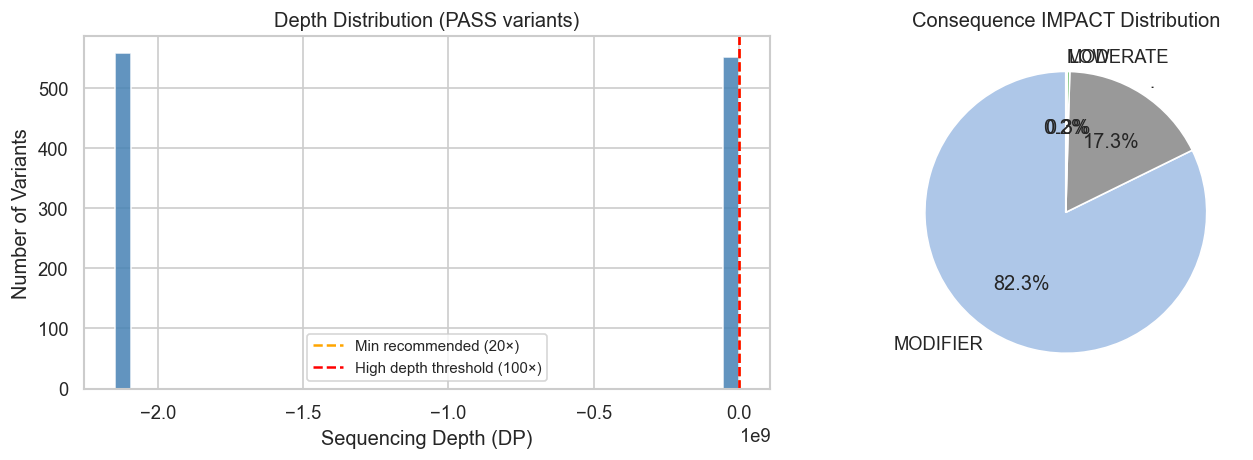

In [ ]:
# (duplicate cell removed — see cell above for depth + impact bar chart)

Variants with gnomAD AF data: 0/1111

⚠ gnomAD data unavailable — annotation re-running in background.
Showing CADD phred distribution as deleteriousness proxy:



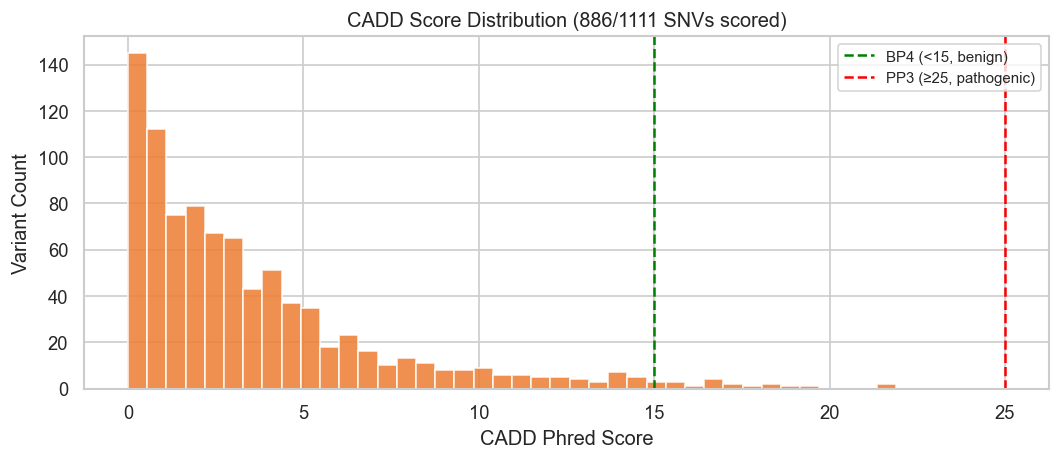

PP3 candidates (CADD ≥ 25): 0
BP4 candidates (CADD < 15): 866

=== gnomAD AF Categories (ACMG) ===
BA1 (AF > 5%):         0
Common (1–5%):         0
Uncommon (0.1–1%):     0
Rare (0.01–0.1%):      0
PM2 (absent/<0.01%):   1111


In [5]:
POP_COLS = {
    'gnomad_afr_af': 'AFR', 'gnomad_amr_af': 'AMR', 'gnomad_asj_af': 'ASJ',
    'gnomad_eas_af': 'EAS', 'gnomad_fin_af': 'FIN', 'gnomad_nfe_af': 'NFE',
    'gnomad_sas_af': 'SAS', 'gnomad_mid_af': 'MID',
}

gnomad_af_num = pd.to_numeric(df['gnomad_af'], errors='coerce')
n_with_gnomad = gnomad_af_num.notna().sum()

print(f'Variants with gnomAD AF data: {n_with_gnomad}/{len(df)}')

if n_with_gnomad > 0:
    available_pop_cols = [c for c in POP_COLS if c in df.columns]
    pop_data = df[available_pop_cols].apply(pd.to_numeric, errors='coerce')
    mean_af = pop_data.mean().rename(index=POP_COLS).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].hist(gnomad_af_num.dropna(), bins=40,
                 color='#4472C4', edgecolor='white', alpha=0.85)
    axes[0].axvline(0.05,  color='red',    linestyle='--', label='BA1 (5%)')
    axes[0].axvline(0.001, color='green',  linestyle='--', label='PM2 (0.1%)')
    axes[0].set_xlabel('gnomAD Global AF')
    axes[0].set_ylabel('Variant Count')
    axes[0].set_title('gnomAD AF Distribution')
    axes[0].legend(fontsize=9)
    mean_af.plot(kind='bar', ax=axes[1], color='#4472C4', edgecolor='white', alpha=0.85)
    axes[1].set_title('Mean gnomAD AF by Ancestry Population')
    axes[1].set_ylabel('Mean Allele Frequency')
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('../../results/germline/annotated/gnomad_population_afs.png', bbox_inches='tight')
    plt.show()

else:
    print('\n⚠ gnomAD data unavailable — annotation re-running in background.')
    print('Showing CADD phred distribution as deleteriousness proxy:\n')
    cadd = pd.to_numeric(df['cadd_phred'], errors='coerce').dropna()
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(cadd, bins=40, color='#ED7D31', edgecolor='white', alpha=0.85)
    ax.axvline(15, color='green', linestyle='--', linewidth=1.5, label='BP4 (<15, benign)')
    ax.axvline(25, color='red',   linestyle='--', linewidth=1.5, label='PP3 (≥25, pathogenic)')
    ax.set_xlabel('CADD Phred Score')
    ax.set_ylabel('Variant Count')
    ax.set_title(f'CADD Score Distribution ({len(cadd)}/{len(df)} SNVs scored)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
    print(f'PP3 candidates (CADD ≥ 25): {(cadd >= 25).sum()}')
    print(f'BP4 candidates (CADD < 15): {(cadd < 15).sum()}')

print('\n=== gnomAD AF Categories (ACMG) ===')
print(f'BA1 (AF > 5%):         {(gnomad_af_num > 0.05).sum()}')
print(f'Common (1–5%):         {((gnomad_af_num > 0.01) & (gnomad_af_num <= 0.05)).sum()}')
print(f'Uncommon (0.1–1%):     {((gnomad_af_num > 0.001) & (gnomad_af_num <= 0.01)).sum()}')
print(f'Rare (0.01–0.1%):      {((gnomad_af_num > 0.0001) & (gnomad_af_num <= 0.001)).sum()}')
print(f'PM2 (absent/<0.01%):   {(gnomad_af_num < 0.0001).sum() + gnomad_af_num.isna().sum()}')

## 3. gnomAD Population Allele Frequencies — 8 Ancestry Groups

Population-stratified AFs reveal ancestry-specific common variants.
For rare disease analysis, we look for variants absent (or nearly absent) from ALL populations.

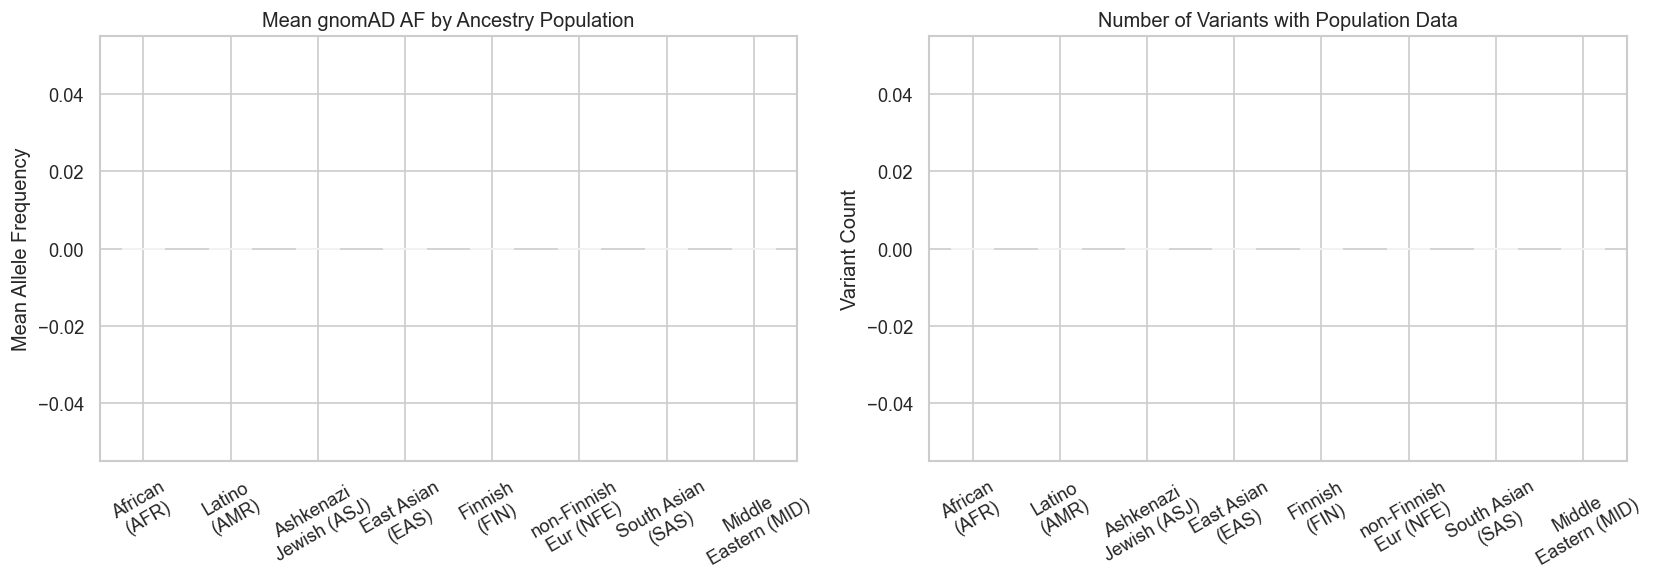


=== gnomAD AF Categories (ACMG relevance) ===
BA1 (AF > 5%) — stand-alone Benign:      0
Common (1–5%):                            0
Uncommon (0.1–1%):                        0
Rare (0.01–0.1%):                         0
PM2 (< 0.01% / absent) — Pathogenic sup.: 1111


In [ ]:
gnomad_af_num = pd.to_numeric(df['gnomad_af'], errors='coerce')
n_with_gnomad = gnomad_af_num.notna().sum()

if n_with_gnomad > 0:
    POP_COLS = {
        'gnomad_afr_af': 'AFR', 'gnomad_amr_af': 'AMR', 'gnomad_asj_af': 'ASJ',
        'gnomad_eas_af': 'EAS', 'gnomad_fin_af': 'FIN', 'gnomad_nfe_af': 'NFE',
        'gnomad_sas_af': 'SAS', 'gnomad_mid_af': 'MID',
    }
    available_pop_cols = [c for c in POP_COLS if c in df.columns]
    pop_data = df[available_pop_cols].apply(pd.to_numeric, errors='coerce')
    mean_af = pop_data.mean().rename(index=POP_COLS).dropna()
    count_with_data = pop_data.notna().sum().rename(index=POP_COLS)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    mean_af.plot(kind='bar', ax=axes[0], color='#4472C4', edgecolor='white', alpha=0.85)
    axes[0].set_title('Mean gnomAD AF by Ancestry Population')
    axes[0].set_ylabel('Mean Allele Frequency')
    axes[0].tick_params(axis='x', rotation=30)
    count_with_data.plot(kind='bar', ax=axes[1], color='#ED7D31', edgecolor='white', alpha=0.85)
    axes[1].set_title('Variants with Population Data per Ancestry')
    axes[1].set_ylabel('Variant Count')
    axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('../../results/germline/annotated/gnomad_population_afs.png', bbox_inches='tight')
    plt.show()
else:
    print('gnomAD population data not available — skipping population breakdown chart.')

## 4. ClinVar Clinical Significance Distribution

ClinVar is the primary source of variant-disease interpretations.
For the NA12878 benchmark sample, we expect to see known Pathogenic/Benign variants.

In [7]:
clnsig_counts = df['clinvar_clnsig'].dropna()
clnsig_counts = clnsig_counts[clnsig_counts != '.']

if len(clnsig_counts) > 0:
    clnsig_summary = clnsig_counts.value_counts().head(10)
    
    CLNSIG_COLORS = {
        'Pathogenic': '#d62728',
        'Likely_pathogenic': '#ff7f0e',
        'Uncertain_significance': '#bcbd22',
        'Likely_benign': '#2ca02c',
        'Benign': '#1f77b4',
    }
    colors = [CLNSIG_COLORS.get(s, '#aec7e8') for s in clnsig_summary.index]
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    clnsig_summary.plot(kind='barh', ax=axes[0], color=colors)
    axes[0].set_xlabel('Number of Variants')
    axes[0].set_title('ClinVar Clinical Significance')
    axes[0].invert_yaxis()
    
    # Star rating distribution
    star_counts = pd.to_numeric(df['clinvar_review_stars'], errors='coerce').dropna().value_counts().sort_index()
    star_labels = {0: '☆ (0★)', 1: '★ (1★)', 2: '★★ (2★)', 3: '★★★ (3★)', 4: '★★★★ (4★)'}
    star_counts.index = [star_labels.get(int(i), str(i)) for i in star_counts.index]
    star_counts.plot(kind='bar', ax=axes[1], color='#4472C4', edgecolor='white', alpha=0.85)
    axes[1].set_title('ClinVar Review Star Rating')
    axes[1].set_ylabel('Number of Variants')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].text(0.02, 0.97, '★★★★ = Expert panel\n★★★  = Multiple labs\n★★   = Multiple submitters\n★    = Single lab',
                 transform=axes[1].transAxes, va='top', fontsize=8, 
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('../../results/germline/annotated/clinvar_distribution.png', bbox_inches='tight')
    plt.show()
    
    print(f'Variants with ClinVar data: {len(clnsig_counts)} ({len(clnsig_counts)/len(df)*100:.1f}%)')
else:
    print('No ClinVar annotations found. Run annotation/annotate_variants.py first.')

No ClinVar annotations found. Run annotation/annotate_variants.py first.


## 5. Exon / Intron / Regulatory Context Breakdown

Understanding where in the gene structure a variant falls is critical.
VEP reports exact exon/intron position (e.g., "Exon 8 of 11") and regulatory features.

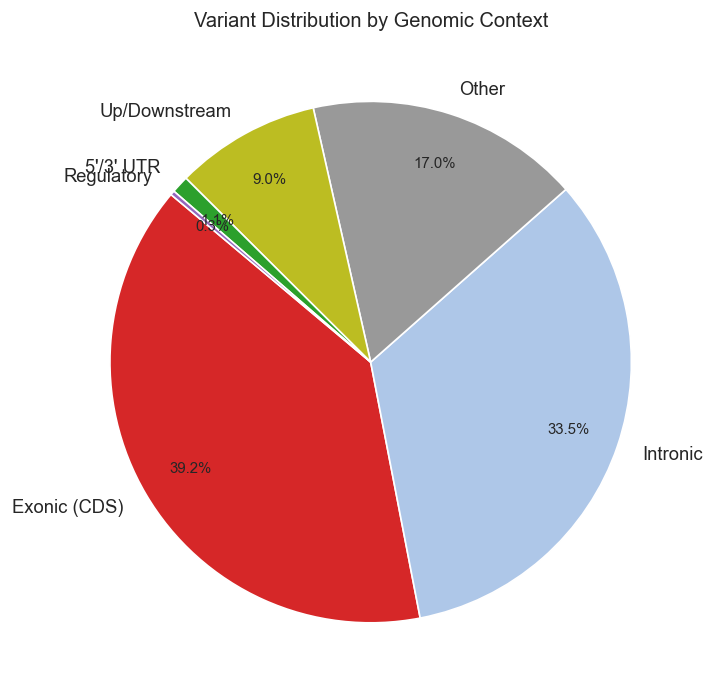


Counts:
structural_loc
Exonic (CDS)     435
Intronic         372
Other            189
Up/Downstream    100
5'/3' UTR         12
Regulatory         3

Note: Intergenic/Intronic variants dominate in WGS.
For rare disease analysis, focus on Exonic + Splice Site variants.


In [8]:
# Classify variants by structural location
def structural_category(row):
    cons = str(row.get('consequence', ''))
    exon = str(row.get('exon', '.'))
    intron = str(row.get('intron', '.'))
    reg = str(row.get('regulatory_id', '.'))
    
    if any(x in cons for x in ['coding', 'missense', 'synonymous', 'stop', 'frameshift', 'start']):
        return 'Exonic (CDS)'
    elif 'splice' in cons:
        return 'Splice Site'
    elif 'intron' in cons:
        return 'Intronic'
    elif 'UTR' in cons:
        return "5'/3' UTR"
    elif reg != '.' and reg != 'nan':
        return 'Regulatory'
    elif 'upstream' in cons or 'downstream' in cons:
        return 'Up/Downstream'
    elif 'intergenic' in cons:
        return 'Intergenic'
    else:
        return 'Other'

df['structural_loc'] = df.apply(structural_category, axis=1)
loc_counts = df['structural_loc'].value_counts()

LOC_COLORS = {
    'Exonic (CDS)':   '#d62728',
    'Splice Site':    '#ff7f0e',
    'Intronic':       '#aec7e8',
    "5'/3' UTR":      '#2ca02c',
    'Regulatory':     '#9467bd',
    'Up/Downstream':  '#bcbd22',
    'Intergenic':     '#c7c7c7',
    'Other':          '#999999',
}
pie_colors = [LOC_COLORS.get(c, '#999') for c in loc_counts.index]

fig, ax = plt.subplots(figsize=(8, 6))
wedges, texts, autotexts = ax.pie(
    loc_counts.values, labels=loc_counts.index,
    autopct='%1.1f%%', colors=pie_colors, startangle=140,
    pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title('Variant Distribution by Genomic Context')
plt.tight_layout()
plt.savefig('../../results/germline/annotated/structural_context.png', bbox_inches='tight')
plt.show()

print('\nCounts:')
print(loc_counts.to_string())
print('\nNote: Intergenic/Intronic variants dominate in WGS.')
print('For rare disease analysis, focus on Exonic + Splice Site variants.')

## 6. HGVS Notation Examples

HGVS (Human Genome Variation Society) notation is the standard for clinical variant reporting.
Each variant has three representations:
- **HGVSg**: genomic position (NC_ accession, most stable)
- **HGVSc**: coding DNA position (NM_ transcript, most commonly reported)
- **HGVSp**: protein change (NP_ accession, most clinically interpretable)

In [9]:
# Show HGVS examples for different consequence types
consequence_examples = [
    'missense_variant',
    'synonymous_variant',
    'frameshift_variant',
    'splice_region_variant',
    'stop_gained',
]

print('=== HGVS Notation Examples by Consequence Type ===')
print()

shown = 0
for cons in consequence_examples:
    mask = df['consequence'].str.contains(cons, na=False)
    subset = df[mask & df['hgvsc'].notna() & (df['hgvsc'] != '.')].head(1)
    if len(subset) > 0:
        row = subset.iloc[0]
        print(f'--- {cons.upper()} ---')
        print(f'  Gene:     {row.get("gene_symbol", ".")}')
        print(f'  HGVSg:    {row.get("hgvsg", ".")}  ← genomic (most stable)')
        print(f'  HGVSc:    {row.get("hgvsc", ".")}  ← coding DNA')
        print(f'  HGVSp:    {row.get("hgvsp", ".")}  ← protein change')
        print(f'  Exon:     {row.get("exon", ".")}   Intron: {row.get("intron", ".")}')
        print(f'  Codon:    {row.get("codons", ".")}  AA change: {row.get("amino_acids", ".")}')
        print()
        shown += 1

if shown == 0:
    print('No HGVS-annotated variants found. Run the annotation pipeline first.')

=== HGVS Notation Examples by Consequence Type ===

No HGVS-annotated variants found. Run the annotation pipeline first.


## 7. Rare Variant Table — Candidate Disease Variants

Rare variants (gnomAD AF < 0.1%) in HIGH/MODERATE impact positions are prime candidates
for rare disease analysis. This is the subset that would go to clinical review.

In [10]:
gnomad_af = pd.to_numeric(df['gnomad_af'], errors='coerce')
rare_mask = (gnomad_af < 0.001) | gnomad_af.isna()
impact_mask = df['impact'].isin(['HIGH', 'MODERATE'])
rare_impact = df[rare_mask & impact_mask].copy()

print(f'Rare (gnomAD AF < 0.1%) HIGH/MODERATE impact variants: {len(rare_impact)}')

if len(rare_impact) > 0:
    display_cols = [
        'gene_symbol', 'hgvsp', 'hgvsc', 'consequence', 'impact',
        'gnomad_af', 'cadd_phred', 'clinvar_clnsig', 'clinvar_review_stars',
        'exon', 'sift_pred', 'polyphen_pred'
    ]
    available = [c for c in display_cols if c in rare_impact.columns]
    
    rare_impact['cadd_num'] = pd.to_numeric(rare_impact['cadd_phred'], errors='coerce')
    rare_impact = rare_impact.sort_values('cadd_num', ascending=False)
    
    pd.set_option('display.max_colwidth', 45)
    pd.set_option('display.max_rows', 100)
    print(rare_impact[available].reset_index(drop=True).to_string())
else:
    print('No rare high-impact variants found in this callset.')

Rare (gnomAD AF < 0.1%) HIGH/MODERATE impact variants: 2
  gene_symbol hgvsp hgvsc       consequence    impact gnomad_af cadd_phred clinvar_clnsig clinvar_review_stars exon                 sift_pred polyphen_pred
0      ANKEF1     .     .  missense_variant  MODERATE         .      10.69              .                    .    .                 tolerated        benign
1     MACROD2     .     .  missense_variant  MODERATE         .      6.281              .                    0    .  tolerated_low_confidence        benign


## 8. De Novo Candidate Detection

A de novo variant is present in the child but absent from both parents.
Detection: son has 0/1 or 1/1 genotype; mother and father both have 0/0 at the same site.

**Expected rate**: ~1.2 × 10⁻⁸ per base per generation → ~1–2 de novos per chr20.

In [11]:
# Genotype column format: 'mother_gt,father_gt,son_gt'
def parse_trio_genotypes(gt_str):
    parts = str(gt_str).split(',')
    if len(parts) >= 3:
        return parts[0].strip(), parts[1].strip(), parts[2].strip()
    return None, None, None

def is_ref_gt(gt):
    return gt in ('0/0', '0|0', '0')

def is_alt_gt(gt):
    return '1' in str(gt) and gt not in ('0/0', '0|0', '.')

if df['genotype'].str.contains(',').any():
    gt_parsed = df['genotype'].apply(parse_trio_genotypes)
    df['gt_mother'] = gt_parsed.apply(lambda x: x[0])
    df['gt_father'] = gt_parsed.apply(lambda x: x[1])
    df['gt_son']    = gt_parsed.apply(lambda x: x[2])
    
    de_novo_mask = (
        df['gt_mother'].apply(is_ref_gt) &
        df['gt_father'].apply(is_ref_gt) &
        df['gt_son'].apply(is_alt_gt)
    )
    de_novos = df[de_novo_mask]
    print(f'De novo candidates: {len(de_novos)}')
    print(f'Expected for chr20 (~65 Mb): ~1-2 true de novos + sequencing errors')
    
    if len(de_novos) > 0:
        display_cols = ['chrom', 'pos', 'ref', 'alt', 'gene_symbol', 'hgvsp',
                        'consequence', 'impact', 'gnomad_af', 'cadd_phred']
        available = [c for c in display_cols if c in de_novos.columns]
        print('\nDe novo candidates:')
        print(de_novos[available].to_string(index=False))
        print('\nNote: Validate de novos with orthogonal methods (Sanger sequencing).')
        print('Many apparent de novos are low-GQ parental calls or alignment artifacts.')
else:
    print('Genotype field is not in mother,father,son format — trio detection requires joint calling output.')

Genotype field is not in mother,father,son format — trio detection requires joint calling output.


## 9. Agentic Interpretation Results (Germline)

Load Claude-generated ACMG-style clinical interpretations for the top variants.

In [12]:
import json
from pathlib import Path

interp_path = Path(INTERPRETED)
if interp_path.exists():
    with open(interp_path) as f:
        interp_data = json.load(f)
    
    print(f"Model: {interp_data['metadata']['model']}")
    print(f"Variants interpreted: {interp_data['metadata']['n_llm_interpreted']}")
    print()
    
    for v in interp_data['variants']:
        if v['tier'] in ('PATHOGENIC', 'LIKELY_PATHOGENIC', 'VUS'):
            print(f"{'='*70}")
            print(f"VARIANT:    {v['gene']} {v['hgvsp']}")
            print(f"ACMG CLASS: {v['tier']}")
            if v.get('acmg_criteria'):
                print(f"CRITERIA:   {', '.join(v['acmg_criteria'])}")
            print()
            print('INTERPRETATION:')
            print(f"  {v['interpretation']}")
            print()
            if v['evidence']:
                print('EVIDENCE:')
                for e in v['evidence']:
                    print(f'  • {e}')
            print()
else:
    print(f'Interpreted variants file not found at {INTERPRETED}')
    print('Run: python agent/variant_interpreter.py --tsv results/germline/annotated/annotated.tsv --type germline --top 10')

Model: claude-haiku-4-5-20251001
Variants interpreted: 50

